Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

Load data

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)


# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.reset_index(drop=True, inplace=True)

Saving merged_data_with_suffix (1).csv to merged_data_with_suffix (1).csv


### ***1-handle object-type columns***

In [ ]:
def clean_currency(x):
    #Remove commas and convert to float
    if isinstance(x, str):
        return float(x.replace(',', ''))
    return x

def clean_percent(x):
    #Convert percentage string to float
    if isinstance(x, str):
        return float(x.replace('%', '')) / 100
    return x

def clean_volume(x):
    #Convert volume strings like 1K, 1M, 1B to numeric
    if isinstance(x, str):
        x = x.upper()
        if 'K' in x:
            return float(x.replace('K',''))*1e3
        elif 'M' in x:
            return float(x.replace('M',''))*1e6
        elif 'B' in x:
            return float(x.replace('B',''))*1e9
        else:
            return float(x.replace(',',''))
    return x


gold_cols = ['Price_Gold','High_Gold','Low_Gold','Open_Gold']

# Clean gold price columns
for col in gold_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_currency)

# Clean percentage and volume
if 'Change%_Gold' in df.columns:
    df['Change%_Gold'] = df['Change%_Gold'].apply(clean_percent)
if 'Volume_Gold' in df.columns:
    df['Volume_Gold'] = df['Volume_Gold'].apply(clean_volume)

# Convert all gold columns to numeric
for col in gold_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes


,0
Date,datetime64[ns]
Price_Gold,float64
High_Gold,float64
Low_Gold,float64
Open_Gold,float64
Volume_Gold,float64
Change%_Gold,float64
Price_Oil,float64
Price_Dollar,float64
High_Dollar,float64


### ***2-multicollinearity***

In [ ]:
#Identify highly correlated pairs

num_df = df.drop(columns=['Date'])
corr = num_df.corr()

threshold = 0.8
high_corr = (
    corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

high_corr[high_corr >= threshold]


High_Stocks   Open_Stocks     0.999958
Price_Stocks  Low_Stocks      0.999952
              High_Stocks     0.999950
Price_Gold    Open_Gold       0.999945
Low_Stocks    Open_Stocks     0.999945
High_Gold     Low_Gold        0.999937
Price_Gold    Low_Gold        0.999924
High_Stocks   Low_Stocks      0.999922
High_Gold     Open_Gold       0.999910
Price_Stocks  Open_Stocks     0.999902
Low_Gold      Open_Gold       0.999890
Price_Gold    High_Gold       0.999856
Price_Dollar  Low_Dollar      0.999596
High_Dollar   Open_Dollar     0.999590
Price_Dollar  High_Dollar     0.999588
Low_Dollar    Open_Dollar     0.999562
High_Dollar   Low_Dollar      0.999446
Price_Dollar  Open_Dollar     0.999095
Open_Gold     Price_Stocks    0.884400
              High_Stocks     0.884399
              Open_Stocks     0.884353
              Low_Stocks      0.884304
Price_Gold    High_Stocks     0.883719
              Price_Stocks    0.883711
              Open_Stocks     0.883659
High_Gold     High_Stocks     0.883618
              Price_Stocks    0.883602
Price_Gold    Low_Stocks      0.883598
High_Gold     Open_Stocks     0.883560
              Low_Stocks      0.883492
Low_Gold      High_Stocks     0.883162
              Price_Stocks    0.883132
              Open_Stocks     0.883086
              Low_Stocks      0.883002
dtype: float64

In [ ]:
#Variance Inflation Factor (VIF)

X = num_df.dropna()

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF
8,High_Dollar,308771.494765
9,Low_Dollar,288261.107046
7,Price_Dollar,262543.091002
10,Open_Dollar,246271.012743
13,High_Stocks,94413.811150
0,Price_Gold,81159.355355
15,Open_Stocks,78631.297117
14,Low_Stocks,76638.784438
12,Price_Stocks,75405.339911
2,Low_Gold,69592.663273


Target Creation (Log Returns)

In [ ]:
df_ts = df.copy()

# Calculate Log Returns and Shift for Next Day Prediction
df_ts['Target'] = np.log(df_ts['Price_Gold']).diff().shift(-1)

# Drop the last row (which has no target due to shift)
df_ts = df_ts.dropna(subset=['Target'])

y = df_ts['Target']
X_base = df_ts.drop(columns=['Date', 'Target'])

Strategy Evaluation

In [ ]:
# Strategy 1: Structural Removal (Keep only Close prices)
X_structural = X_base[[
    'Price_Gold','Price_Dollar','Price_Stocks','Price_Oil',
    'Volume_Gold','Volume_Dollar','Volume_Stocks',
    'Change%_Gold'
]].copy()

# Strategy 2: Feature Engineering (Spreads/Deltas)
X_spreads = pd.DataFrame(index=df_ts.index)
assets = ['Gold','Dollar','Stocks']
for a in assets:
    X_spreads[f'{a}_HL'] = df_ts[f'High_{a}'] - df_ts[f'Low_{a}'] # High-Low Spread
    X_spreads[f'{a}_OC'] = df_ts[f'Price_{a}'] - df_ts[f'Open_{a}'] # Open-Close Spread
    X_spreads[f'Price_{a}'] = df_ts[f'Price_{a}']

X_spreads['Price_Oil'] = df_ts['Price_Oil']
X_spreads['Volume_Gold'] = df_ts['Volume_Gold']
X_spreads['Volume_Dollar'] = df_ts['Volume_Dollar']
X_spreads['Volume_Stocks'] = df_ts['Volume_Stocks']
X_spreads['Change%_Gold'] = df_ts['Change%_Gold']

# Strategy 3: PCA (Defined in pipeline later)
X_pca = X_base.copy()

# Strategy 4: VIF Pruning (Drop highly correlated columns automatically)
X_vif = X_base.copy()
corr = X_vif.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
X_vif = X_vif.drop(columns=to_drop)

In [ ]:
def lag_align(X, y):
    """Aligns features and target after creating lags."""
    X_lag = X.shift(1).dropna()
    return X_lag, y.loc[X_lag.index]

# Prepare datasets
X_sets = {
    'Base': lag_align(X_base, y),
    'Structural': lag_align(X_structural, y),
    'Spreads': lag_align(X_spreads, y),
    'VIF Reduced': lag_align(X_vif, y),
    'PCA': lag_align(X_pca, y)
}

# Evaluation Function
def evaluate_ts(X, y, model, splits=5):
    tscv = TimeSeriesSplit(n_splits=splits)
    rmse, r2 = [], []
    for tr, te in tscv.split(X):
        model.fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict(X.iloc[te])
        rmse.append(np.sqrt(mean_squared_error(y.iloc[te], pred)))
        r2.append(r2_score(y.iloc[te], pred))
    return np.mean(rmse), np.mean(r2)

# Define Models
ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
ridge_pca = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('ridge', Ridge(alpha=1.0))])

# Run Comparison
results = {}
for name, (X_i, y_i) in X_sets.items():
    model = ridge_pca if name == 'PCA' else ridge
    results[name] = evaluate_ts(X_i, y_i, model)

results_df = pd.DataFrame(results, index=['RMSE','R2']).T
print("Strategy Performance:")
print(results_df.sort_values('RMSE'))

Strategy Performance:
                 RMSE        R2
PCA          0.010949 -0.025534
Structural   0.011367 -0.094958
VIF Reduced  0.011367 -0.094958
Base         0.011419 -0.103564
Spreads      0.011464 -0.111841


In [ ]:
# Prepare Data & Target
df_processed = df.copy()

# Next-day log return (target)
df_processed['Target'] = np.log(df_processed['Price_Gold']).diff().shift(-1)
df_processed = df_processed.dropna(subset=['Target'])

# Select Features for PCA
# Numeric columns only
cols_for_pca = df_processed.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude target and volume (kept separate)
exclude_cols = ['Target', 'Volume_Gold']
cols_for_pca = [c for c in cols_for_pca if c not in exclude_cols]

print(f"PCA will be applied on {len(cols_for_pca)} features")

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed[cols_for_pca])

#  Apply PCA (95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Number of retained components: {pca.n_components_}")

#PCA Components DataFrame
pc_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca, columns=pc_columns, index=df_processed.index)

# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols_for_pca,
    columns=pc_columns
)

# Sort loadings by absolute contribution for PC1 (example)
pc1_top = loadings['PC1'].abs().sort_values(ascending=False).head(10)
print("\nTop contributors to PC1:")
print(pc1_top)

# Final Dataset Assembly

df_final = pd.concat([
    df_processed[['Date']],     # Date
    df_pca,                      # PCA components
    df_processed[['Volume_Gold']],  # Volume kept raw
    df_processed[['Target']]    # Target
], axis=1)

# Final Check
print("\nFinal dataset shape:", df_final.shape)
df_final.head()


PCA will be applied on 16 features
Number of retained components: 5

Top contributors to PC1:
Open_Gold        0.332787
Price_Gold       0.332718
High_Gold        0.332704
Low_Gold         0.332674
High_Stocks      0.328032
Open_Stocks      0.327976
Price_Stocks     0.327971
Low_Stocks       0.327905
Volume_Stocks    0.266741
Price_Oil        0.230934
Name: PC1, dtype: float64

Final dataset shape: (9932, 8)


,Date,PC1,PC2,PC3,PC4,PC5,Volume_Gold,Target
0,1986-01-02,-2.660327,5.654217,-0.459694,-0.472461,1.469801,NaN,0.003339
1,1986-01-03,-2.635933,5.883378,0.221372,0.226736,1.554982,NaN,0.002119
2,1986-01-06,-2.632553,5.849480,0.139243,0.142622,1.553919,NaN,0.006330
3,1986-01-07,-2.630132,5.687852,0.434735,0.445885,1.505882,NaN,0.009867
4,1986-01-08,-2.612902,5.808618,0.675573,0.692703,1.554886,NaN,0.011243


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols_for_pca,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
loadings.sort_values('PC1', key=abs, ascending=False).head(10)


,PC1,PC2,PC3,PC4,PC5
Open_Gold,0.332787,-0.053076,0.000731,-0.001191,-0.083965
Price_Gold,0.332718,-0.053552,0.004424,0.002336,-0.082106
High_Gold,0.332704,-0.053658,-0.004429,-0.006684,-0.081382
Low_Gold,0.332674,-0.053952,-0.000078,-0.002311,-0.079484
High_Stocks,0.328032,0.090818,-0.005533,-0.000199,-0.162289
Open_Stocks,0.327976,0.090684,-0.005581,-0.000133,-0.164681
Price_Stocks,0.327971,0.090642,-0.005462,-0.000151,-0.165362
Low_Stocks,0.327905,0.090502,-0.005633,-0.000117,-0.167941
Volume_Stocks,0.266741,-0.141209,0.001832,-0.009882,0.657319
Price_Oil,0.230934,-0.240519,-0.005544,0.004108,0.587401


In [ ]:
for pc in loadings.columns:
    print(f"\nEquation for {pc}:")
    terms = [f"{w:.4f}*{f}" for f, w in loadings[pc].items()]
    equation = " + ".join(terms)
    print(equation)



Equation for PC1:
0.3327*Price_Gold + 0.3327*High_Gold + 0.3327*Low_Gold + 0.3328*Open_Gold + 0.0088*Change%_Gold + 0.2309*Price_Oil + 0.0245*Price_Dollar + 0.0240*High_Dollar + 0.0246*Low_Dollar + 0.0241*Open_Dollar + 0.0024*Volume_Dollar + 0.3280*Price_Stocks + 0.3280*High_Stocks + 0.3279*Low_Stocks + 0.3280*Open_Stocks + 0.2667*Volume_Stocks

Equation for PC2:
-0.0536*Price_Gold + -0.0537*High_Gold + -0.0540*Low_Gold + -0.0531*Open_Gold + 0.0012*Change%_Gold + -0.2405*Price_Oil + 0.4684*Price_Dollar + 0.4683*High_Dollar + 0.4686*Low_Dollar + 0.4685*Open_Dollar + 0.0000*Volume_Dollar + 0.0906*Price_Stocks + 0.0908*High_Stocks + 0.0905*Low_Stocks + 0.0907*Open_Stocks + -0.1412*Volume_Stocks

Equation for PC3:
0.0044*Price_Gold + -0.0044*High_Gold + -0.0001*Low_Gold + 0.0007*Open_Gold + 0.6975*Change%_Gold + -0.0055*Price_Oil + -0.0042*Price_Dollar + 0.0008*High_Dollar + -0.0008*Low_Dollar + 0.0045*Open_Dollar + 0.7164*Volume_Dollar + -0.0055*Price_Stocks + -0.0055*High_Stocks + -0.00

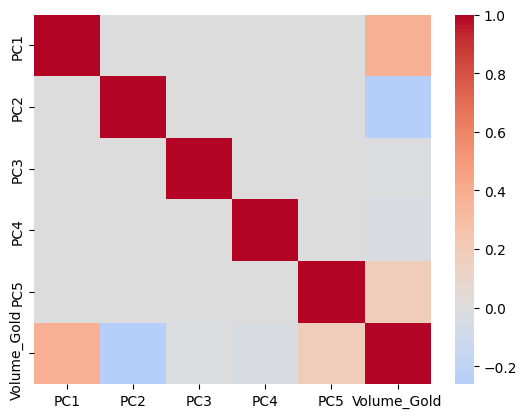

In [ ]:
corr = df_final.drop(columns=['Date','Target']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()


### 3-Handling Missing Values

In [ ]:
df_final.isnull().sum()

,0
Date,0
PC1,0
PC2,0
PC3,0
PC4,0
PC5,0
Volume_Gold,1778
Target,0


In [ ]:
def evaluate_missing_strategy(X, y, name):
    model = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []

    for train_idx, test_idx in tscv.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx])
        rmse_scores.append(np.sqrt(mean_squared_error(y.iloc[test_idx], pred)))

    return np.mean(rmse_scores)

# Strategy 1: Drop Feature (Volume)
# Removes the Volume_Gold column entirely, keeps all rows.
df_drop_col = df_final.drop(columns=['Volume_Gold']).dropna()
score_drop = evaluate_missing_strategy(df_drop_col.drop(columns=['Date','Target']), df_drop_col['Target'], "Drop Volume")

# Strategy 2: Impute Mean
# Fills missing volume with the average volume, keeps all rows.
df_mean = df_final.copy()
df_mean['Volume_Gold'] = df_mean['Volume_Gold'].fillna(df_mean['Volume_Gold'].mean())
score_mean = evaluate_missing_strategy(df_mean.drop(columns=['Date','Target']), df_mean['Target'], "Impute Mean")

# Strategy 3: Drop Rows
# Removes only the specific days where Volume data is missing.
df_drop_rows = df_final.dropna(subset=['Volume_Gold'])
score_drop_rows = evaluate_missing_strategy(df_drop_rows.drop(columns=['Date','Target']), df_drop_rows['Target'], "Drop Rows")

print(f"RMSE (Drop Volume): {score_drop:.5f}")
print(f"RMSE (Impute Mean): {score_mean:.5f}")
print(f"RMSE (Drop Rows):   {score_drop_rows:.5f}")

# Decision Logic
scores = {
    'Drop Volume': score_drop,
    'Impute Mean': score_mean,
    'Drop Rows': score_drop_rows
}

best_strategy = min(scores, key=scores.get)
print(f"Decision: Best strategy is {best_strategy}")

if best_strategy == 'Drop Volume':
    df_final = df_final.drop(columns=['Volume_Gold'])
elif best_strategy == 'Impute Mean':
    df_final['Volume_Gold'] = df_final['Volume_Gold'].fillna(df_final['Volume_Gold'].mean())
else: # Drop Rows
    df_final = df_final.dropna(subset=['Volume_Gold'])

print(f"Final dataset shape: {df_final.shape}")

RMSE (Drop Volume): 0.01024
RMSE (Impute Mean): 0.01035
RMSE (Drop Rows):   0.01089
Decision: Best strategy is Drop Volume
Final dataset shape: (9932, 7)


In [ ]:
df_final.isnull().sum()

,0
Date,0
PC1,0
PC2,0
PC3,0
PC4,0
PC5,0
Target,0


In [ ]:
# Check that observations are ordered chronologically, which is required for time series analysis
df_final['Date'].is_monotonic_increasing


True

In [ ]:
# Assess the central tendency, dispersion, and extreme values of the target variable to identify potential anomalies
df_final['Target'].describe()


,Target
count,9932.000000
mean,0.000255
std,0.010236
min,-0.098105
25%,-0.004377
50%,0.000234
75%,0.005329
max,0.088303


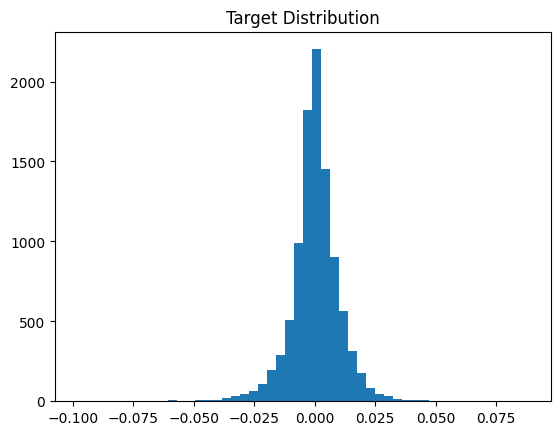

In [ ]:
plt.hist(df_final['Target'], bins=50)
plt.title("Target Distribution")
plt.show()


In [ ]:
# Evaluate the presence of a unit root in the target series using the Augmented Dickey-Fuller (ADF) test to confirm stationarity

from statsmodels.tsa.stattools import adfuller

adf = adfuller(df_final['Target'])
print(f"ADF p-value: {adf[1]}")


ADF p-value: 0.0


A p-value below 0.05 indicates that the null hypothesis of a unit root can be rejected ,Suggesting that the target series is stationary


In [ ]:
filename_output = 'gold_data_cleaned_pca.csv'
df_final.to_csv(filename_output, index=False)

print(f"File saved as {filename_output}")
files.download(filename_output)

File saved as gold_data_cleaned_pca.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>